# Week 3 - Probability Distributions 1 and 2

Learning contents:

1. Frequenist's approach
    - Bernoulli distribution function
    - Maximum Likelihood
    - Display distribution
2. Bayesian approach
    - Binomial distribution
    - Display Binomial distribution for different m
    - Maximum posterior
3. Multinomial variables
    - Generate data
    - Frequenist's approach
        - Multinomial Bernoulli distribution function
        - Maximum likelihood
4. Gaussian distribution
    - Distribution function
    - Generate data
    - Display data
    - Frequenist's approach
        - Maximum likelihood
        - Display distribution
    - Bayesian approach
        - Generate data
        - Variance is known, mean is unknown
        - Display mean estimation for different N

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from math import exp, sqrt
from collections import Counter
from scipy.special import comb
from scipy.stats import beta
from scipy.stats import multivariate_normal, norm
from scipy.special import factorial 

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

The code listed below defines 2 functions: 'weighted_coin' gives an output of a random experiment involving a single toss of a loaded or weighted coin. The probability of getting 'heads' is 0.7, whereas the probability of getting 'tails' is 0.3. In the case of heads, the function outputs 1, else it outputs 0.

Generate_data() then generates samples from the 'weighted_coin' random experiment. We generate 10,000 samples using this function.

In [2]:
random.seed(2605)

def weighted_coin(heads=0.7, tails=0.3):
    total = heads + tails
    value = random.random() * total
    result = 0 if value <= tails else 1
    return result


def generate_data(size):
    return list(map(
        lambda i: weighted_coin(),
        range(size)
    ))


train_size = 10000
train_data = generate_data(train_size)
print(len(np.argwhere(train_data)))         # 7045 passer meget fint med p(krone) = 0.7

7045


<BarContainer object of 2 artists>

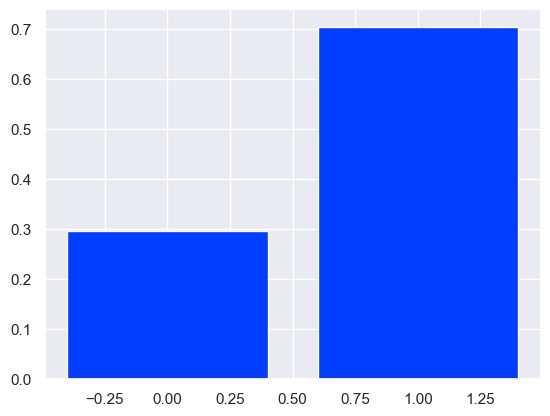

In [3]:
counter = Counter(train_data)
plt.bar(counter.keys(), list(map(lambda a: a / train_size, counter.values())))

## 1) Frequenist's approach

### 1.1) Bernoulli distribution function

write the function 'bern' that outputs the probability density function value of a bernoulli ramdom variable 'x' and paramater 'mu' (see slide 7 in lecture 5).

In [4]:
def bern(x, mu):
    return mu**x * (1 - mu)**(1 - x)
import sympy as sp
bern(1, sp.symbols("mu")) # Passer med at p(x = 1|u) = u, som jeg har udledt for før. 

mu

### 1.2) Maximum Likelihood

write the function mu_maximum_likelihood_bern that takes data points train_data and should return the Maximum Likelihood estimate of the parameter 'mu' of the Bernoulli distribution (slide 9 of lecture 5). Is your estimate of 'mu' close to the theoretical value? Also, convince yourself that the 'train_data' that you generated above does belong to Bernoulli distribution!

In [5]:
def mu_maximum_likelihood_bern(train_data):
    m = np.sum(train_data)
    N = len(train_data)
    uML = m/N
    return uML

mu_ml = mu_maximum_likelihood_bern(train_data)
print(mu_ml)

0.7045


### 1.3) Display distribution

The function below plots the probability density (or mass) function of a Bernoulli random variable. Why is this function discrete?

In [6]:
def display_bernoulli(mu, color='b'):

    #xs = np.linspace(0., 1., 100)
    ys = list(map(
        lambda x: bern(x, mu),
        [0,1]
    ))

    plt.bar([0,1],ys)

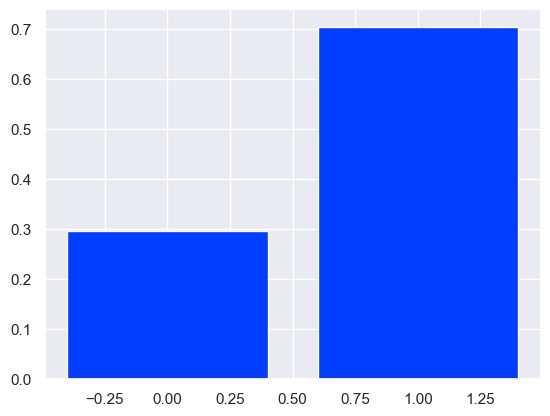

In [7]:
display_bernoulli(mu_ml)

## 2) Bayesian approach

### 2.1) Binomial distribution

write a function that gives the value of probability density function for Binomial random variable with input parameters 'm', 'N' and 'mu'. Note that 'm' denotes the number of successes in 'N' bernoulli trials or expriments and represents a binomial random variable. 

In [8]:
def binomialNormFactor(m, N): 
    return factorial(N)/(factorial(m) * factorial(N - m))

def binomial(m, N, mu):
    # For binomial fordelinger, så må middelværdien være lige med sandsynligheden. 
    p = mu
    pminN = binomialNormFactor(m, N) * (p ** (m)) * (1 - p)**(N - m)
    return pminN

### 2.2) Display Binomial distribution for different m

In [9]:
def display_binomial(N, mu):
    xs = list(range(N))
    ys = list(map(
        lambda m: binomial(m, N, mu),
        xs
    ))
    
    plt.bar(xs, ys)
    plt.xlabel('m')

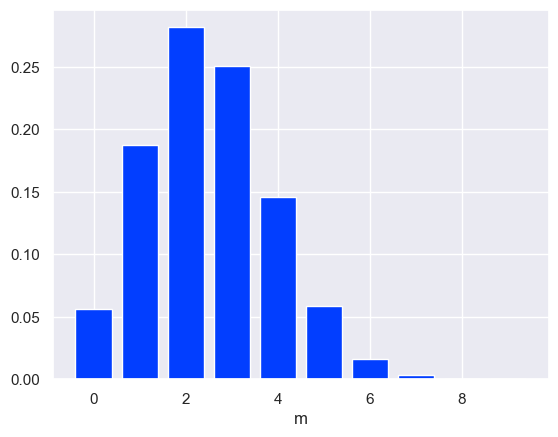

In [10]:
display_binomial(10, 0.25)

### 2.3) Maximum posterior

write a function 'mu_maximum_posterior_bern' which takes parameters 'm', 'N', 'a', 'b' and should return the Maximum Posterior estimate of the parameter 'mu' of the Bernoulli distribution (see the slide 18 in lecture 5). Compare this estimate with that obtained earlier in section 1.2 using maximum likelihood estimator. How the two estimators compare for large values of 'N'?

In [11]:
def mu_maximum_posterior_bern(m, N, a, b):
    l = N - m
    return (m + a) / (m + a + l + b)

In [25]:
print(mu_maximum_posterior_bern(sum(train_data), train_size, 0.1, 0.1))


0.7044959100817983


De er næsten det samme, men det er også fordi at m & N >> a & b. 

## 3) Multinomial variables

### 3.1) Generate data

generate samples of the multinomial random variable using 1-of-K scheme (see slide 21 of week 5). While the code is provided here, it is highly recommended to understand how the function has been implemented.

In [ ]:
np.random.seed(26)

def generate_multinomial_data(size, probabilities):
    numbers = np.random.choice(len(probabilities), size, 1, probabilities)      # [p(X = 1) = 0.5,  ..., p(X = 1) = 0.1] -> [0, 0, 1, 0, 0]
    # print(numbers)
    # print(numbers.size)
    result = np.zeros((numbers.size, len(probabilities)))                       # A = 0 in R^{100, 5}
    result[np.arange(numbers.size), numbers] = 1                                # ([0; 100],  [tilfældigt tal fra 0 -> 5])
    return result
    
probabilities=[0.5, 0.1, 0.2, 0.1, 0.1]
multinomial_data = generate_multinomial_data(100, probabilities)
multinomial_data

[0 1 2 2 3 0 0 0 2 0 0 1 0 2 0 0 4 4 1 0 2 1 4 0 4 2 2 0 2 2 2 4 3 2 0 2 0
 0 1 0 1 3 0 0 4 4 4 0 3 2 0 0 0 2 4 2 0 1 0 1 0 0 0 2 4 1 0 1 4 2 0 4 2 0
 4 0 0 0 2 0 0 4 0 0 3 0 2 0 2 0 0 0 2 0 0 2 4 0 0 3]


array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0.

### 3.2) Frequenist's approach

#### 3.2.1) Multinomial distribution function

Write a function bern_multi(xs, mus) that computes the probability of a single multinomial outcome.

xs: a one-hot encoded vector of length 𝐾
K, representing the observed outcome (which category occurred).
Example: [0,1,0,0] means category 2 was observed.

mus: probability vector of length 𝐾
K, where each entry is the probability of a category and all entries sum to 1.
Example: [0.2, 0.5, 0.3].

(see slide 21 of week 5)

In [34]:
def bern_multi(xs, mus):    
    """
    For funktioner som x hvor kun 1 værdi ikke er 0, og at den også er 1 betyder for mig, at jeg bare plukker middelværdierne ud.
    Resten af middelværdierne tilføjer bare et * 1 til den plukkede.
    """
    i = np.where(xs)        # Hvor er den ikke 0? Men 1? 
    p = mus[i] 
    return p

#### 3.2.2) Maximum likelihood

`mu_maximum_likelihood_multinomial_bern' takes multinomial data points, 'multinomial_data', and return Maximum Likelihood estimate of the parameters 'mus' of the Multinomial distribution (See slide 23 in Lecture 5). Print the estimated parameter values and compare those with the actual values. If they are different, how could you bring them closer?

In [44]:
def mu_maximum_likelihood_multinomial_bern(multinomial_data):
    N, _ = multinomial_data.shape
    m = np.sum(multinomial_data, 0)          # Summer over rækkerne. Kolonnerne er kategorier, så antallet af successer må findes til hver kategori
    
    muk_ML = m/N
    return muk_ML 

multi_mu_ml = mu_maximum_likelihood_multinomial_bern(multinomial_data)
multi_mu_ml

# array([0.46, 0.1 , 0.23, 0.06, 0.15]) er da tæt på [0.5, 0.1, 0.2, 0.1, 0.1] som jeg lavede mit data udfra. 
# Hvis jeg vil have endnu bedre resultater, så må jeg lade N -> ∞

array([0.46, 0.1 , 0.23, 0.06, 0.15])

## 4) Gaussian distribution

### 4.1) Multivariate Gaussian Distribution Function

Write a function multi_gaussian(x, mean, covariance) that returns the probability density of the Gaussian distribution.

x: data point (scalar or vector)

mean: mean (scalar for 1D, vector for multivariate)

covariance: variance (1D) or covariance matrix (multivariate)

You may either:

Use the built-in method scipy.stats.multivariate_normal.pdf, or

Implement the formula in slide 6 (week 6) from scratch.

Test your function with both 1D and 2D cases to build intuition.

In [ ]:
def multi_gaussian(x, mean, covariance):
    fordeling = multivariate_normal(mean, covariance)
    pdens= fordeling.pdf(x)
    return pdens 

u = 2
sd = 0.5
var = sd**2
multi_gaussian(3, u, var)

# Den funger.

np.float64(0.10798193302637613)

### 4.2) Generate data

The function below generates 'size' number of random samples from multivariate Gaussian distribution with a specified mean and covariance.

In [59]:
def generate_multi_gaussian_data(size, mean, covariance):
    return np.array(multivariate_normal(mean=mean, cov=covariance).rvs(size=size, random_state=26))

target_mean = [1.7, -4]
target_cov = [[1, 0.1], [0.1, 1]]
multi_gaussian_data = generate_multi_gaussian_data(50, target_mean, target_cov)

### 4.3) Display data

See the output of the code below and understand the Gaussian contour plots. What do the smaller contours (in the center) represent in that figure? Where do the majority of the data points (blue dots) lie and why? 

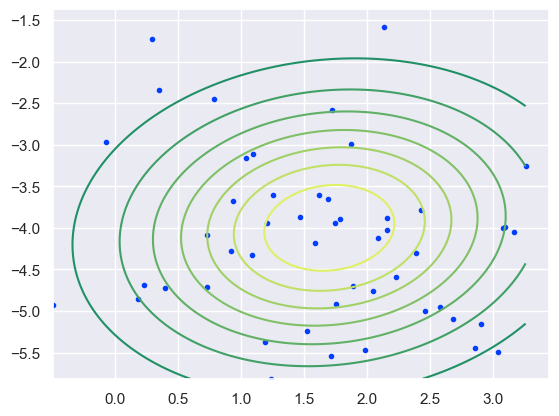

In [61]:
plt.plot(multi_gaussian_data[:, 0], multi_gaussian_data[:, 1], '.')

def display_gaussian_contour(data, mean, covariance, cmap='summer'):

    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    plt.contour(x, y, multivariate_normal(mean, covariance).pdf(pos), cmap=cmap)

display_gaussian_contour(multi_gaussian_data, target_mean, target_cov)

### 4.4) Parameter Estimation using Frequenist's approach

#### 4.4.1) Maximum likelihood

write the `multi_gaussian_mu_maximum_likelihood` function that takes Gaussian distributed data points `multi_gaussian_data` and should return Maximum Likelihood estimate of the mean of Multivariate Gaussian distribution (Slide 10 of lecture 6).

In [67]:
def multi_gaussian_mu_maximum_likelihood(multi_gaussian_data):
    N, _ = multi_gaussian_data.shape
    muML = np.sum(multi_gaussian_data, axis = 0) / N 
    return muML

g_mu_ml = multi_gaussian_mu_maximum_likelihood(multi_gaussian_data)
g_mu_ml

# array([ 1.64301733, -4.13747801]) vs [1.7, -4]

array([ 1.64301733, -4.13747801])

Write the function `multi_gaussian_covariance_maximum_likelihood` that takes Gaussian data points `multi_gaussian_data` and Maximum Likelihood estimate for `mu` (`g_mu_ml`) and should return Maximum Likelihood estimate of the covariance matrix of that distribution (slide 12 of lecture 6).

In [82]:
def multi_gaussian_covariance_maximum_likelihood(multi_gaussian_data, g_mu_ml):
    N, _= multi_gaussian_data.shape
    distanceFromMean = multi_gaussian_data - g_mu_ml                # [x_00, x_01] - [u_0, u_1]
    
    # R^{2 x 100} . R^{100 x 2} -> R^{2 x 2} som jeg forventer af en covariance matrice.
    
    # formlen ser distancen som værende en R^{2 x 100} matrice fra start af, derfor bliver min matricers transponering modsat deres.
    cov = distanceFromMean.T @ distanceFromMean
    cov_norm = ( 1/(N - 1) ) * cov
    return cov_norm
    
    
g_cov_ml = multi_gaussian_covariance_maximum_likelihood(multi_gaussian_data, g_mu_ml)
g_cov_ml

array([[ 0.84757357, -0.18427121],
       [-0.18427121,  0.97482937]])

#### 4.4.2) Display distribution

Displaying and comparing between the estimated distribution and the true distribution. Should and Do they appear close together? 

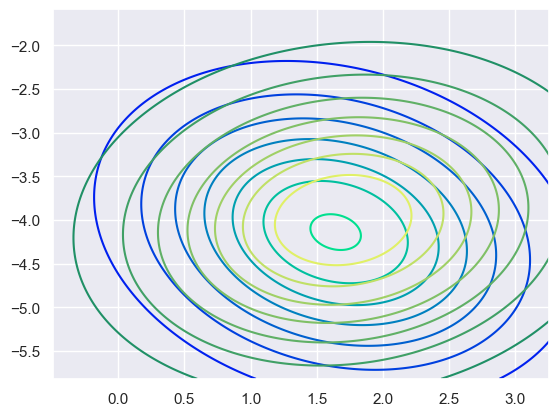

In [83]:
display_gaussian_contour(multi_gaussian_data, g_mu_ml, g_cov_ml, cmap='winter')
display_gaussian_contour(multi_gaussian_data, target_mean, target_cov, cmap='summer')

### 4.5) Parameter Estimation using Bayesian approach

Here, we will implement Gaussian parameter estimation methods using the Bayesian approach. The generated Gaussian data points will be univariate in this case.  

#### 4.5.1) Generate data

Generate 50 samples of univariate Gaussian data with mean=0.8 and variance=0.1

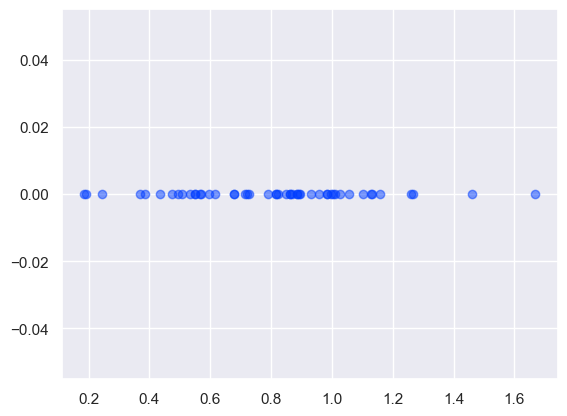

In [84]:
def generate_gaussian_data(size, mean, variance):
    return np.array(norm(mean, sqrt(variance)).rvs(size=size, random_state=26))

g_mean = 0.8
g_variance = 0.1
gaussian_data = generate_gaussian_data(50, g_mean, g_variance)

plt.scatter(gaussian_data, [0] * len(gaussian_data), alpha=0.5)

#### 4.5.2) Estimating mean distribution when the variance is known

write the function `multi_gaussian_mu_maximum_posterior` that takes data points `gaussian_data`, prior mean `mu0` and prior variance `variance0`, actual variance of the distribution, `variance`, and should return the parameters (mean and variance) of the Posterior Mean distribution (see the last 2 equations in slide 15 of lecture 6). See section 2.3.6 for details.

In [102]:
def multi_gaussian_mu_maximum_posterior(gaussian_data, mu0, variance0, variance):
    # Så nu arbejder vi med 1D data igen.
    # Min funktion tager 2D, så jeg laver lige lidt magi.
    # mu_N: 
    data_mult = gaussian_data[:, np.newaxis]
    N, _= data_mult.shape
    uml = multi_gaussian_mu_maximum_likelihood(data_mult)[0]
    un = (variance/(N * variance0 + variance)) * mu0 + (N * variance0/(N * variance0 + variance)) * uml
    
    # var_N: 
    varN = 1/( (1/(variance0) + N/variance))

    return un, varN

g_mu_map, g_mu_var_map = multi_gaussian_mu_maximum_posterior(gaussian_data, 0, g_variance, g_variance)
g_mu_map, g_mu_var_map

(np.float64(0.7873049121325899), 0.00196078431372549)

#### 4.5.3) Display mean estimation for different values of N

Looking at the plots below, why does the mean distribution gets more and more concentrated around true value as the number of samples increase? What benefits this Bayesian approach offers over maximum likelihood approach?

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_41795/884568618.py:3: RuntimeWarning: invalid value encountered in divide
  muML = np.sum(multi_gaussian_data, axis = 0) / N


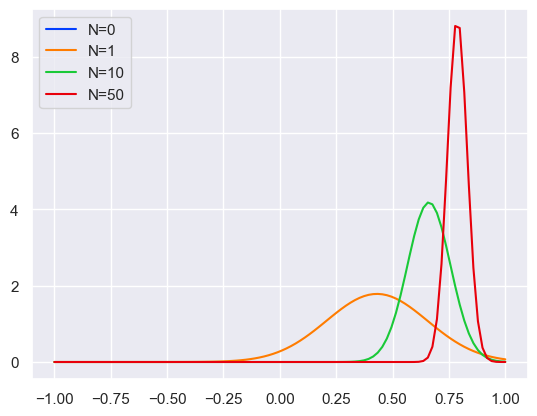

In [103]:
def display_mu_map(gaussian_data, mu0, variance0, variance):
    g_mu_map, g_mu_var_map = multi_gaussian_mu_maximum_posterior(gaussian_data, 0, g_variance, g_variance)
    x = np.linspace(-1, 1, 100)
    y = norm(g_mu_map, sqrt(g_mu_var_map)).pdf(x)
    plt.plot(x, y, label='N=' + str(len(gaussian_data)))
    plt.legend()

display_mu_map(gaussian_data[:0], 0, g_variance, g_variance)
display_mu_map(gaussian_data[:1], 0, g_variance, g_variance)
display_mu_map(gaussian_data[:10], 0, g_variance, g_variance)
display_mu_map(gaussian_data, 0, g_variance, g_variance)